# Modelo de fuga de clientes (Customer Churn)
## Aprendizaje supervisado — clasificación binaria

Este notebook está pensado como **material guiado para una clase**. La idea no es memorizar código, sino comprender el flujo completo de un problema de clasificación:

**datos históricos → variable objetivo → entrenamiento → predicción → evaluación → interpretación**

El conjunto `clientes_churn.csv` es **sintético y educativo**. Imita la estructura típica de datos de una empresa de servicios.

## Objetivos de la clase

Al finalizar este ejemplo deberíamos poder explicar:

1. Por qué la fuga de clientes es un problema de **clasificación supervisada**.
2. Qué diferencia existe entre variables predictoras (`X`) y variable objetivo (`y`).
3. Para qué separamos datos de **entrenamiento** y **prueba**.
4. Qué significa `random_state=0`.
5. Cómo funciona una **regresión logística** para clasificación.
6. Cómo leer una **matriz de confusión**, Precision, Recall, F1 y ROC-AUC.
7. Cómo interpretar coeficientes y **odds ratio**.
8. Cómo funciona un **árbol de decisión**, el índice Gini y `max_depth`.
9. Cómo detectar una señal de **sobreajuste**.

In [1]:
# Librerías principales.
# Si trabajas en un entorno donde alguna no está instalada, puedes instalarla antes.
# !pip install pandas numpy scikit-learn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

pd.set_option('display.max_columns', None)

## 1. Cargar el conjunto de datos

Cada fila representa un cliente. La columna **`Churn`** indica si el cliente abandonó (`Yes`) o no (`No`).

En un caso real, las variables predictoras deben corresponder a información disponible **antes** de saber si el cliente abandonará.

In [2]:
df = pd.read_csv('clientes_churn.csv')

print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (1600, 13)


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,TechSupport,PaperlessBilling,PaymentMethod,SeniorCitizen,Partner,Dependents,Churn
0,C100000,7,97.29,644.36,One year,Fiber optic,No,Yes,Mailed check,0,No,No,No
1,C100001,56,85.60,4638.95,Month-to-month,Fiber optic,Yes,Yes,Mailed check,0,Yes,No,No
2,C100002,48,81.05,4015.75,Two year,Fiber optic,No,No,Electronic check,0,No,Yes,No
3,C100003,32,18.00,602.70,One year,No,Yes,No,Credit card,0,No,No,No
4,C100004,32,75.74,2558.90,Month-to-month,Fiber optic,No,Yes,Bank transfer,0,Yes,Yes,Yes


### Diccionario rápido de variables

- `tenure`: meses que lleva el cliente en la empresa.
- `MonthlyCharges`: cargo mensual.
- `TotalCharges`: cargos acumulados.
- `Contract`: tipo de contrato.
- `InternetService`: tipo de servicio de internet.
- `TechSupport`: posee o no soporte técnico.
- `PaperlessBilling`: facturación electrónica.
- `PaymentMethod`: forma de pago.
- `SeniorCitizen`: indicador 0/1.
- `Partner`, `Dependents`: características del hogar.
- **`Churn`: variable objetivo.**

Como `Churn` tiene dos resultados posibles, estamos frente a una **clasificación binaria**.

In [3]:
# Revisión básica de tipos y valores faltantes.
print(df.info())
print('\nValores faltantes por columna:')
print(df.isna().sum())

print('\nDistribución de la variable objetivo:')
print(df['Churn'].value_counts())
print('\nPorcentaje:')
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1600 non-null   object 
 1   tenure            1600 non-null   int64  
 2   MonthlyCharges    1600 non-null   float64
 3   TotalCharges      1600 non-null   float64
 4   Contract          1600 non-null   object 
 5   InternetService   1600 non-null   object 
 6   TechSupport       1600 non-null   object 
 7   PaperlessBilling  1600 non-null   object 
 8   PaymentMethod     1600 non-null   object 
 9   SeniorCitizen     1600 non-null   int64  
 10  Partner           1600 non-null   object 
 11  Dependents        1600 non-null   object 
 12  Churn             1600 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 162.6+ KB
None

Valores faltantes por columna:
customerID          0
tenure              0
MonthlyCharges      0
TotalCharges        0

## 2. ¿Por qué esto es aprendizaje supervisado?

Porque durante el entrenamiento **conocemos la respuesta correcta** de los ejemplos históricos.

- Variables de entrada: contrato, antigüedad, cargos, soporte, etc.
- Etiqueta conocida: `Churn = Yes/No`.

El algoritmo intenta aprender una relación entre las entradas y esa etiqueta para luego clasificar clientes nuevos.

> **Idea clave:** supervisado significa que entrenamos con ejemplos donde la respuesta objetivo ya está etiquetada.

In [4]:
# customerID es un identificador, no debería usarse para aprender patrones.
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_features = [
    'Contract', 'InternetService', 'TechSupport',
    'PaperlessBilling', 'PaymentMethod', 'Partner', 'Dependents'
]

print('X:', X.shape)
print('y:', y.shape)

X: (1600, 11)
y: (1600,)


## 3. Separar entrenamiento y prueba

Usaremos el 80% para entrenar y el 20% para evaluar.

`random_state=0` **no significa que dejemos de usar aleatoriedad**. Fija una semilla para que la división aleatoria pueda repetirse y obtener las mismas filas en entrenamiento y prueba en ejecuciones futuras.

`stratify=y` mantiene aproximadamente la misma proporción de `Yes/No` en ambos conjuntos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)
print('\nProporción Churn en entrenamiento:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporción Churn en prueba:')
print(y_test.value_counts(normalize=True).round(3))

Entrenamiento: (1280, 11)
Prueba: (320, 11)

Proporción Churn en entrenamiento:
Churn
No     0.805
Yes    0.195
Name: proportion, dtype: float64

Proporción Churn en prueba:
Churn
No     0.806
Yes    0.194
Name: proportion, dtype: float64


## 4. Preparar los datos

Los modelos necesitan números:

- Las variables numéricas se estandarizan con `StandardScaler`.
- Las variables categóricas se convierten en columnas binarias con `OneHotEncoder`.

Usamos un `Pipeline` para que el mismo procesamiento aplicado al entrenamiento se aplique correctamente a los datos nuevos.

In [6]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

logistic_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(max_iter=1000, random_state=0))
])

logistic_model.fit(X_train, y_train)
print('Modelo entrenado correctamente.')

Modelo entrenado correctamente.


## 5. Predicción: clase y probabilidad

La regresión logística puede entregar una **probabilidad** de pertenecer a la clase positiva.

Ejemplo conceptual:

- Probabilidad de fuga = 0.82 → alto riesgo.
- Probabilidad de fuga = 0.15 → bajo riesgo.

Con un umbral de 0.50, normalmente convertimos esa probabilidad en una clase `Yes/No`.

In [7]:
y_pred_log = logistic_model.predict(X_test)

# Buscamos la posición de la clase 'Yes' dentro del modelo.
classes = logistic_model.named_steps['classifier'].classes_
yes_index = list(classes).index('Yes')
y_prob_log = logistic_model.predict_proba(X_test)[:, yes_index]

preview = X_test.head(8).copy()
preview['Real'] = y_test.head(8).values
preview['Prediccion'] = y_pred_log[:8]
preview['Prob_Churn'] = np.round(y_prob_log[:8], 3)
preview

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,TechSupport,PaperlessBilling,PaymentMethod,SeniorCitizen,Partner,Dependents,Real,Prediccion,Prob_Churn
1119,36,84.65,3370.69,Two year,Fiber optic,No,Yes,Mailed check,1,No,No,No,No,0.118
340,46,46.92,2256.21,Month-to-month,DSL,Yes,No,Credit card,0,No,No,No,No,0.096
1228,12,94.46,1023.44,Month-to-month,Fiber optic,Yes,Yes,Credit card,1,Yes,Yes,Yes,Yes,0.682
580,7,94.31,619.19,Month-to-month,Fiber optic,No,Yes,Bank transfer,0,Yes,Yes,Yes,Yes,0.654
582,8,68.24,454.72,Month-to-month,DSL,No,No,Mailed check,0,Yes,No,Yes,No,0.314
1132,58,116.74,6146.72,One year,Fiber optic,Yes,No,Electronic check,0,Yes,No,No,No,0.053
1189,1,87.16,88.58,Month-to-month,DSL,No,No,Bank transfer,0,Yes,No,Yes,No,0.425
1060,56,93.68,4538.76,One year,Fiber optic,Yes,Yes,Mailed check,0,No,No,Yes,No,0.048


## 6. Matriz de confusión

En una clasificación binaria podemos separar los resultados en cuatro casos:

- **TN (verdadero negativo):** era `No` y predijimos `No`.
- **FP (falso positivo):** era `No`, pero predijimos `Yes`.
- **FN (falso negativo):** era `Yes`, pero predijimos `No`.
- **TP (verdadero positivo):** era `Yes` y predijimos `Yes`.

Si usamos el orden de etiquetas `['No', 'Yes']`, `sklearn` organiza la matriz así:

```
[[TN, FP],
 [FN, TP]]
```

TN = 244
FP = 14
FN = 52
TP = 10


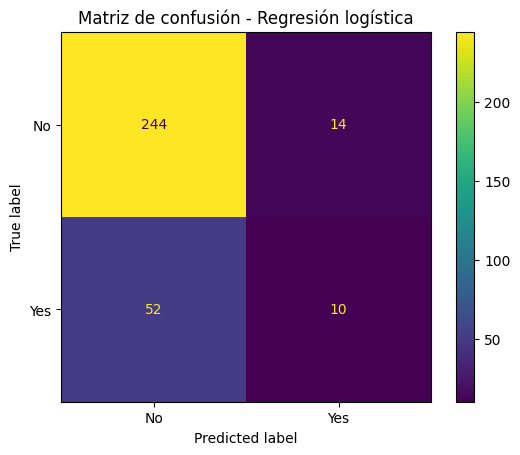

In [8]:
cm = confusion_matrix(y_test, y_pred_log, labels=['No', 'Yes'])
tn, fp, fn, tp = cm.ravel()

print('TN =', tn)
print('FP =', fp)
print('FN =', fn)
print('TP =', tp)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes']).plot()
plt.title('Matriz de confusión - Regresión logística')
plt.show()

### Cómo pensar los errores en churn

No todos los errores tienen el mismo costo comercial:

- **Falso positivo:** creemos que un cliente se irá, pero en realidad se quedará. Podríamos gastar una oferta de retención innecesariamente.
- **Falso negativo:** creemos que se quedará, pero realmente se irá. Podríamos perder la oportunidad de intervenir.

Por eso **Accuracy no siempre es suficiente** para evaluar el modelo.

In [9]:
# Convertimos la respuesta real a 0/1 para ROC-AUC.
y_test_binary = (y_test == 'Yes').astype(int)
y_pred_binary = (y_pred_log == 'Yes').astype(int)

metrics_log = {
    'Accuracy': accuracy_score(y_test_binary, y_pred_binary),
    'Precision': precision_score(y_test_binary, y_pred_binary),
    'Recall': recall_score(y_test_binary, y_pred_binary),
    'F1': f1_score(y_test_binary, y_pred_binary),
    'ROC_AUC': roc_auc_score(y_test_binary, y_prob_log)
}

pd.Series(metrics_log).round(3)

Accuracy     0.794
Precision    0.417
Recall       0.161
F1           0.233
ROC_AUC      0.775
dtype: float64

### Interpretación rápida de métricas

- **Accuracy:** proporción total de predicciones correctas.
- **Precision:** de los clientes que marqué como fuga, ¿cuántos realmente se fueron?
- **Recall / Sensibilidad:** de los clientes que realmente se fueron, ¿cuántos detecté?
- **F1:** balance entre Precision y Recall.
- **ROC-AUC:** capacidad del modelo para ordenar casos positivos por encima de negativos a través de distintos umbrales.

En conjuntos desbalanceados conviene mirar **F1, Recall, Precision y ROC-AUC**, no solamente Accuracy.

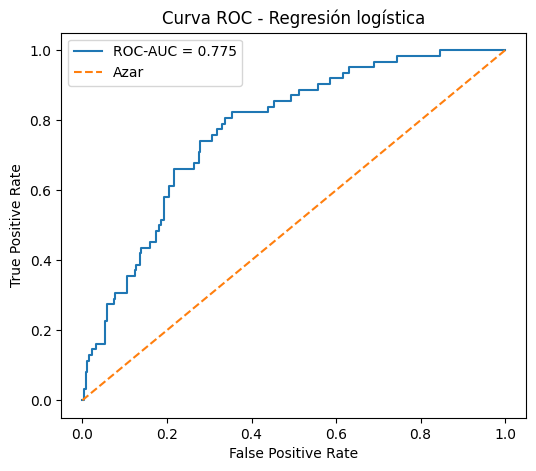

In [10]:
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {metrics_log['ROC_AUC']:.3f}")
plt.plot([0, 1], [0, 1], '--', label='Azar')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Regresión logística')
plt.legend()
plt.show()

## 7. Coeficientes y Odds Ratio en regresión logística

La regresión logística modela **log-odds**.

Un coeficiente positivo tiende a aumentar la probabilidad de la clase positiva (`Churn = Yes`), mientras que uno negativo tiende a disminuirla, manteniendo las demás variables constantes.

Si aplicamos `exp(coeficiente)`, obtenemos el **odds ratio**:

- `odds ratio > 1`: aumenta las odds de fuga.
- `odds ratio < 1`: disminuye las odds de fuga.
- `odds ratio ≈ 1`: efecto pequeño.

Esto **no significa** que el coeficiente sea directamente el cambio en la probabilidad.

In [11]:
feature_names = logistic_model.named_steps['preprocess'].get_feature_names_out()
coefs = logistic_model.named_steps['classifier'].coef_[0]

coef_table = pd.DataFrame({
    'Variable_transformada': feature_names,
    'Coeficiente': coefs,
    'Odds_Ratio': np.exp(coefs)
}).sort_values('Coeficiente', ascending=False)

print('Variables que más empujan hacia Churn = Yes:')
display(coef_table.head(8).round(3))

print('Variables que más empujan hacia Churn = No:')
display(coef_table.tail(8).sort_values('Coeficiente').round(3))

Variables que más empujan hacia Churn = Yes:


,Variable_transformada,Coeficiente,Odds_Ratio
4,cat__Contract_Month-to-month,1.432,4.188
1,num__MonthlyCharges,0.523,1.687
8,cat__InternetService_Fiber optic,0.400,1.492
10,cat__TechSupport_No,0.259,1.295
16,cat__PaymentMethod_Electronic check,0.218,1.244
13,cat__PaperlessBilling_Yes,0.182,1.200
3,num__SeniorCitizen,0.169,1.184
15,cat__PaymentMethod_Credit card,0.088,1.092


Variables que más empujan hacia Churn = No:


,Variable_transformada,Coeficiente,Odds_Ratio
6,cat__Contract_Two year,-0.831,0.435
5,cat__Contract_One year,-0.600,0.549
2,num__TotalCharges,-0.310,0.733
11,cat__TechSupport_Yes,-0.258,0.773
9,cat__InternetService_No,-0.238,0.788
0,num__tenure,-0.224,0.799
14,cat__PaymentMethod_Bank transfer,-0.200,0.819
12,cat__PaperlessBilling_No,-0.181,0.834


## 8. Árbol de decisión para churn

Un árbol va haciendo preguntas del tipo:

> `tenure <= 17.5`  
> `Contract = Month-to-month`  
> `MonthlyCharges <= ...`

En clasificación, una forma común de decidir las divisiones es la **impureza de Gini**.

- Gini bajo → el nodo contiene principalmente una clase.
- Gini alto → las clases están más mezcladas.

Los árboles son fáciles de interpretar, pero pueden crecer demasiado y **sobreajustarse**.

In [12]:
tree_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', DecisionTreeClassifier(
        criterion='gini',
        max_depth=4,       # limita el tamaño del árbol
        min_samples_leaf=20,
        random_state=0
    ))
])

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
train_acc_tree = tree_model.score(X_train, y_train)
test_acc_tree = tree_model.score(X_test, y_test)

print('Accuracy entrenamiento:', round(train_acc_tree, 3))
print('Accuracy prueba:', round(test_acc_tree, 3))

Accuracy entrenamiento: 0.821
Accuracy prueba: 0.803


### Sobreajuste

Una señal clásica es:

> **rendimiento muy alto en entrenamiento + rendimiento claramente peor en prueba**.

Eso puede indicar que el árbol memorizó detalles del conjunto de entrenamiento que no generalizan.

Para controlar la complejidad podemos usar, entre otros:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- poda posterior mediante `ccp_alpha`

En este ejemplo usamos principalmente `max_depth=4` y `min_samples_leaf=20` como **pre-poda**.

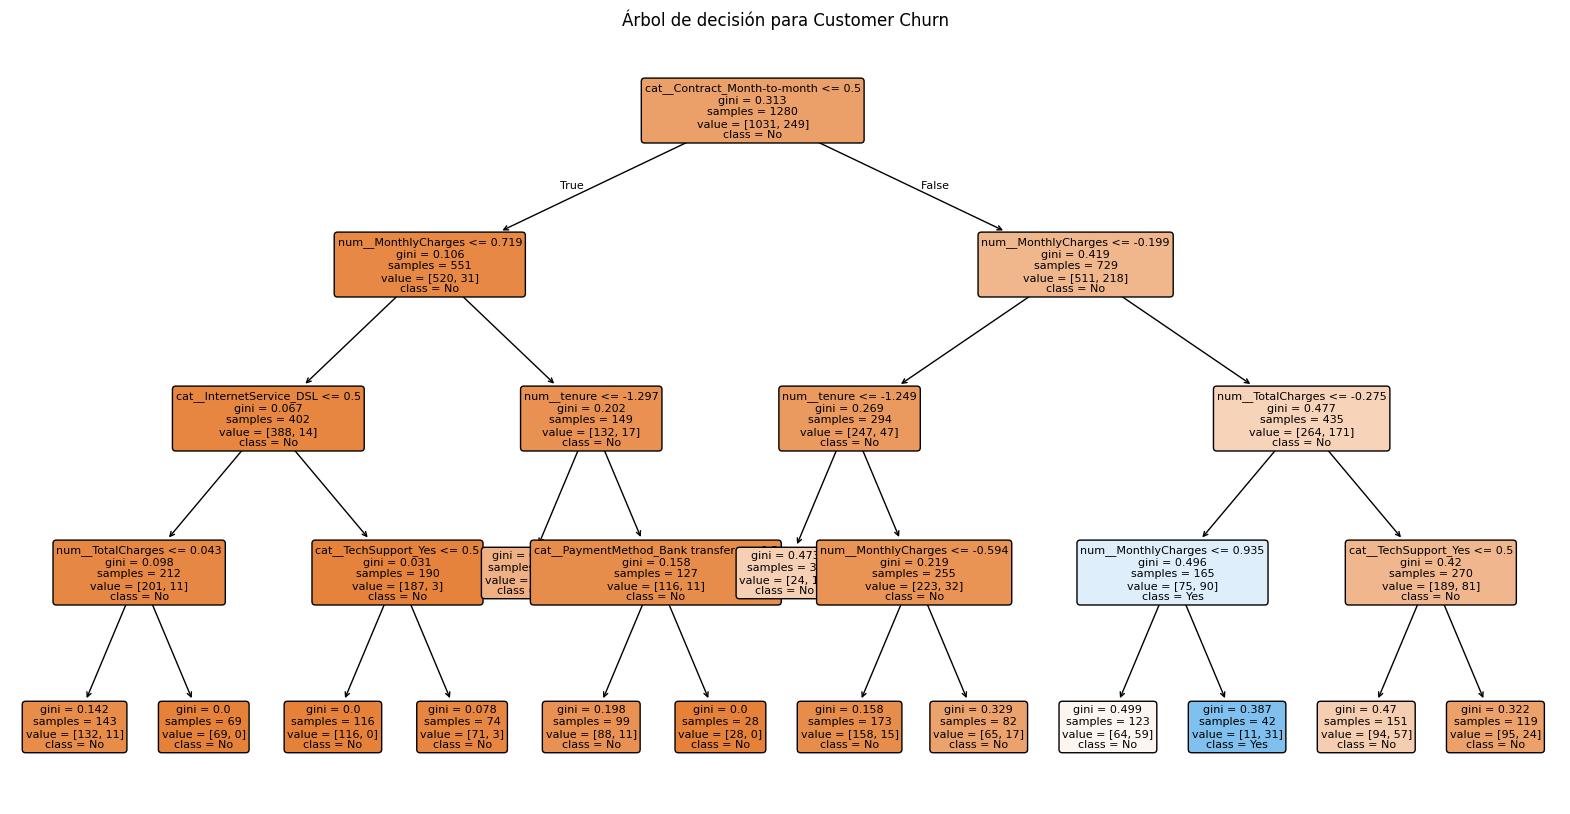

In [13]:
# Visualizamos el árbol. Usamos plot_tree para no depender de Graphviz.
transformed_names = tree_model.named_steps['preprocess'].get_feature_names_out()
tree_classifier = tree_model.named_steps['classifier']

plt.figure(figsize=(20, 10))
plot_tree(
    tree_classifier,
    feature_names=transformed_names,
    class_names=tree_classifier.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Árbol de decisión para Customer Churn')
plt.show()

## 9. Cómo leer un nodo de árbol

Supongamos que aparece un nodo como este:

```text
tenure <= 17.5
gini = 0.391
samples = 5625
value = [4125, 1500]
class = not churn
```

Interpretación:

- La división evalúa si `tenure <= 17.5`.
- Llegaron **5625 observaciones** a ese nodo.
- `value = [4125, 1500]` muestra cuántas observaciones hay de cada clase, respetando el orden de clases usado por el modelo.
- Si el orden es `[not churn, churn]`, entonces **4125 pertenecen a no abandono** y 1500 a abandono.
- La clase mayoritaria del nodo es `not churn`.

> **Importante:** siempre conviene verificar el orden de `model.classes_` antes de interpretar `value`.

In [14]:
# Importancia de variables del árbol después del preprocesamiento.
importance_table = pd.DataFrame({
    'Variable_transformada': transformed_names,
    'Importancia': tree_classifier.feature_importances_
}).sort_values('Importancia', ascending=False)

importance_table.head(12).round(3)

,Variable_transformada,Importancia
4,cat__Contract_Month-to-month,0.425
1,num__MonthlyCharges,0.302
2,num__TotalCharges,0.148
0,num__tenure,0.067
11,cat__TechSupport_Yes,0.049
14,cat__PaymentMethod_Bank transfer,0.006
7,cat__InternetService_DSL,0.003
3,num__SeniorCitizen,0.000
5,cat__Contract_One year,0.000
8,cat__InternetService_Fiber optic,0.000


## 10. Comparar los dos modelos

No existe una métrica universalmente mejor. La decisión depende del objetivo del negocio.

Por ejemplo, si nos importa **detectar la mayor cantidad posible de clientes que efectivamente se irán**, Recall puede ser especialmente relevante.

In [15]:
# Métricas del árbol para la misma clase positiva: Churn = Yes.
y_pred_tree_binary = (y_pred_tree == 'Yes').astype(int)

# Probabilidad de Yes para ROC-AUC.
tree_yes_index = list(tree_classifier.classes_).index('Yes')
y_prob_tree = tree_model.predict_proba(X_test)[:, tree_yes_index]

comparison = pd.DataFrame({
    'Regresion_logistica': [
        accuracy_score(y_test_binary, y_pred_binary),
        precision_score(y_test_binary, y_pred_binary),
        recall_score(y_test_binary, y_pred_binary),
        f1_score(y_test_binary, y_pred_binary),
        roc_auc_score(y_test_binary, y_prob_log)
    ],
    'Arbol_decision': [
        accuracy_score(y_test_binary, y_pred_tree_binary),
        precision_score(y_test_binary, y_pred_tree_binary),
        recall_score(y_test_binary, y_pred_tree_binary),
        f1_score(y_test_binary, y_pred_tree_binary),
        roc_auc_score(y_test_binary, y_prob_tree)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC'])

comparison.round(3)

,Regresion_logistica,Arbol_decision
Accuracy,0.794,0.803
Precision,0.417,0.462
Recall,0.161,0.097
F1,0.233,0.160
ROC_AUC,0.775,0.750


# Resumen de estudio — preguntas guiadas con respuesta

### 1. ¿Por qué churn es clasificación supervisada?
Porque usamos ejemplos históricos con una **etiqueta conocida** (`Yes/No`) y queremos clasificar casos nuevos.

### 2. ¿Para qué sirve el conjunto de prueba?
Para evaluar el modelo con **datos que no utilizó para aprender**. Esto permite estimar mejor su capacidad de generalización.

### 3. ¿Qué hace `random_state=0`?
Fija una semilla para que procesos aleatorios, como la división train/test, puedan **reproducirse**.

### 4. ¿Cómo se identifica un falso positivo en la matriz de confusión?
Es un caso realmente negativo (`No`) que el modelo predice como positivo (`Yes`). Con orden `['No','Yes']`, está en la posición superior derecha.

### 5. ¿Qué señal sugiere sobreajuste?
Que el rendimiento en entrenamiento sea **mucho mejor** que el rendimiento en prueba.

### 6. ¿Cómo podemos limitar un árbol para combatir sobreajuste?
Por ejemplo con `max_depth`, `min_samples_leaf`, `min_samples_split` o poda con `ccp_alpha`.

### 7. ¿Qué mide Gini?
El grado de **impureza o mezcla de clases** dentro de un nodo. Las divisiones buscan generar nodos más puros.

### 8. ¿Qué significa un coeficiente positivo en regresión logística?
Manteniendo el resto constante, incrementa los **log-odds** de la clase positiva. Su exponencial es el odds ratio.

### 9. ¿Para qué sirve la curva ROC?
Para evaluar cómo cambia la relación entre verdaderos positivos y falsos positivos al modificar el umbral de clasificación.

### 10. ¿Por qué F1 puede ser más útil que Accuracy?
Porque combina Precision y Recall y resulta útil cuando las clases están desbalanceadas o cuando importan los errores sobre la clase positiva.

## Para cerrar la clase

El objetivo de un modelo de churn no es solamente obtener una buena métrica. Debemos poder responder:

1. **¿A quién estamos intentando detectar?**
2. **¿Qué tipo de error nos cuesta más?**
3. **¿El modelo funciona en clientes que no vio durante el entrenamiento?**
4. **¿Qué variables parecen asociarse a la fuga?**
5. **¿Qué acción comercial tomaríamos con la predicción?**

Ese razonamiento conecta Machine Learning con una decisión real de negocio.